#                           Homework 1

Импорты:

In [1]:
import os
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from solution_utils import (
    read_raw, to_dialogs_frame, to_turns_frame,
    language_counts, analyze_dialog_lengths_by_turns, plot_dialog_lengths_by_turns, 
    analyze_dialog_lengths_by_chars, plot_dialog_lengths_by_chars)


In [2]:
DATA = os.environ.get("HW1_TRAIN", "dataset/hw1_train.jsonl")
TRAIN_PATH = os.environ.get("HW1_TRAIN", "dataset/hw1_train.jsonl")
DATA_PATH = os.environ.get("HW1_DATA", "dataset/hw1_train.jsonl")
LABELS_PATH = os.environ.get("HW1_LABELS", DATA_PATH)
PREDICTIONS_PATH = os.environ.get("HW1_PREDICTIONS", "predictions.csv")

records = read_raw(DATA)
general_data_df = to_dialogs_frame(records) # собрали основную информацию
user_rep_df = to_turns_frame(records)       # спустились на уровень labels
print(len(records), "диалогов,", user_rep_df.shape[0], "user-реплик")


10000 диалогов, 20051 user-реплик


## Разведочный анализ

Посмотрим на табличку с общей информацие по диалогам

In [3]:
general_data_df.head()

,dialog_id,language,n_user_turns,n_turns,n_user_replies,n_asst_replies,user_chars,asst_chars,total_chars,task_type,reaction
0,d094012177e,en,7,14,7,7,8453,10492,18945,analysis,positive
1,d306fbe61fe,en,8,16,8,8,1278,32255,33533,information_seeking,neutral
2,dd6905952c7,en,5,10,5,5,3326,11938,15264,creation,neutral
3,d767a675896,en,6,12,6,6,1115,9253,10368,information_seeking,negative
4,d7a6280ce8e,en,8,16,8,8,374,7528,7902,information_seeking,negative


Посмотрим на табличку с информацией отдельно по репликам

In [4]:
user_rep_df.head(9)

,dialog_id,language,position,is_last,is_first,text_len,task_type,state,reaction,reaction_reason
0,d094012177e,en,0,False,True,7924,analysis,continuation,None,None
1,d094012177e,en,1,False,False,77,analysis,continuation,neutral,None
2,d094012177e,en,2,False,False,141,open-ended_discovery,continuation,positive,Humor
3,d094012177e,en,3,False,False,118,creation,continuation,neutral,None
4,d094012177e,en,4,False,False,25,creation,continuation,negative,Negative_Feedback
5,d094012177e,en,5,False,False,90,open-ended_discovery,continuation,positive,Humor
6,d094012177e,en,6,True,False,78,information_seeking,continuation,neutral,None
7,d306fbe61fe,en,0,False,True,142,information_seeking,newtopic,None,None
8,d306fbe61fe,en,1,False,False,134,information_seeking,continuation,neutral,None


1. Проверим однородность датасета, везде ли будут одинаковые метки? Нет ли таких вариантов, где пропустили какой-то признак.

In [5]:
keys_sets = Counter(frozenset(r.keys()) for r in records)
for keys, count in keys_sets.items():
    print(count, "записей с ключами:", sorted(keys))

10000 записей с ключами: ['dialog_id', 'labels', 'language', 'n_user_turns', 'turns']


2. Проверим аналогично однороднойсть label.

In [6]:
label_keys_sets = Counter(
    frozenset((r.get("labels") or {}).keys()) for r in records
)
for keys, count in label_keys_sets.items():
    print(count, "записей с ключами labels:", sorted(keys))

3000 записей с ключами labels: ['reaction', 'task_type', 'user_turns']
7000 записей с ключами labels: []


*Замечаем, что только 3 000 из 10 000 диалогов размечены. Дальше будем думать что с ними делать.*

3. Проверим, совпадает ли количество реплик пользователя, заявленное в метке и в действительсности

In [7]:
mismatch = []
for r in records:
    n_expected = r.get("n_user_turns")
    n_actual = sum(1 for t in r["turns"] if t["role"] == "user")
    if n_expected != n_actual:
        mismatch.append((r["dialog_id"], n_expected, n_actual))
print("диалогов с несовпадением n_user_turns и фактического числа user-реплик:", len(mismatch))
for row in mismatch[:5]:
    print(row)

диалогов с несовпадением n_user_turns и фактического числа user-реплик: 0


In [8]:
counts = language_counts(general_data_df)
print("Абсолютные числа:")
display(counts)

print("Доли:")
display((counts / len(general_data_df)).round(4))

Абсолютные числа:


language
en    9929
ru      71
Name: count, dtype: int64

Доли:


language
en    0.9929
ru    0.0071
Name: count, dtype: float64

--- user ---
  min=5, max=10, mean=6.70, median=6.0, std=1.60
--- assistant ---
  min=5, max=10, mean=6.70, median=6.0, std=1.60
--- total ---
  min=10, max=20, mean=13.40, median=12.0, std=3.19


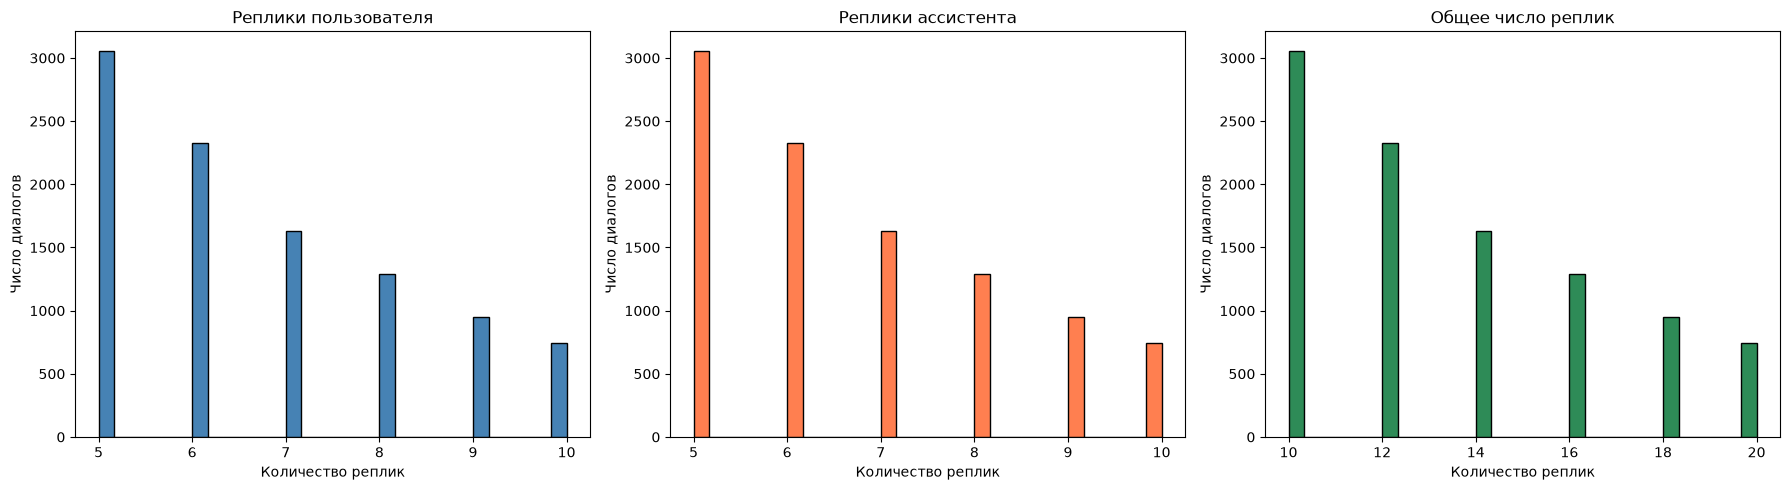

--- user ---
  min=43, max=42987, mean=2339.59, median=914.0, std=3819.33
  квантили: q25=433.0, q50=914.0, q75=2464.5, q90=5932.4
--- assistant ---
  min=18, max=54682, mean=9975.99, median=8912.0, std=6758.55
  квантили: q25=4745.0, q50=8912.0, q75=14033.5, q90=19054.7
--- total ---
  min=181, max=59794, mean=12315.58, median=10800.5, std=8411.35
  квантили: q25=6030.8, q50=10800.5, q75=16916.2, q90=22333.9


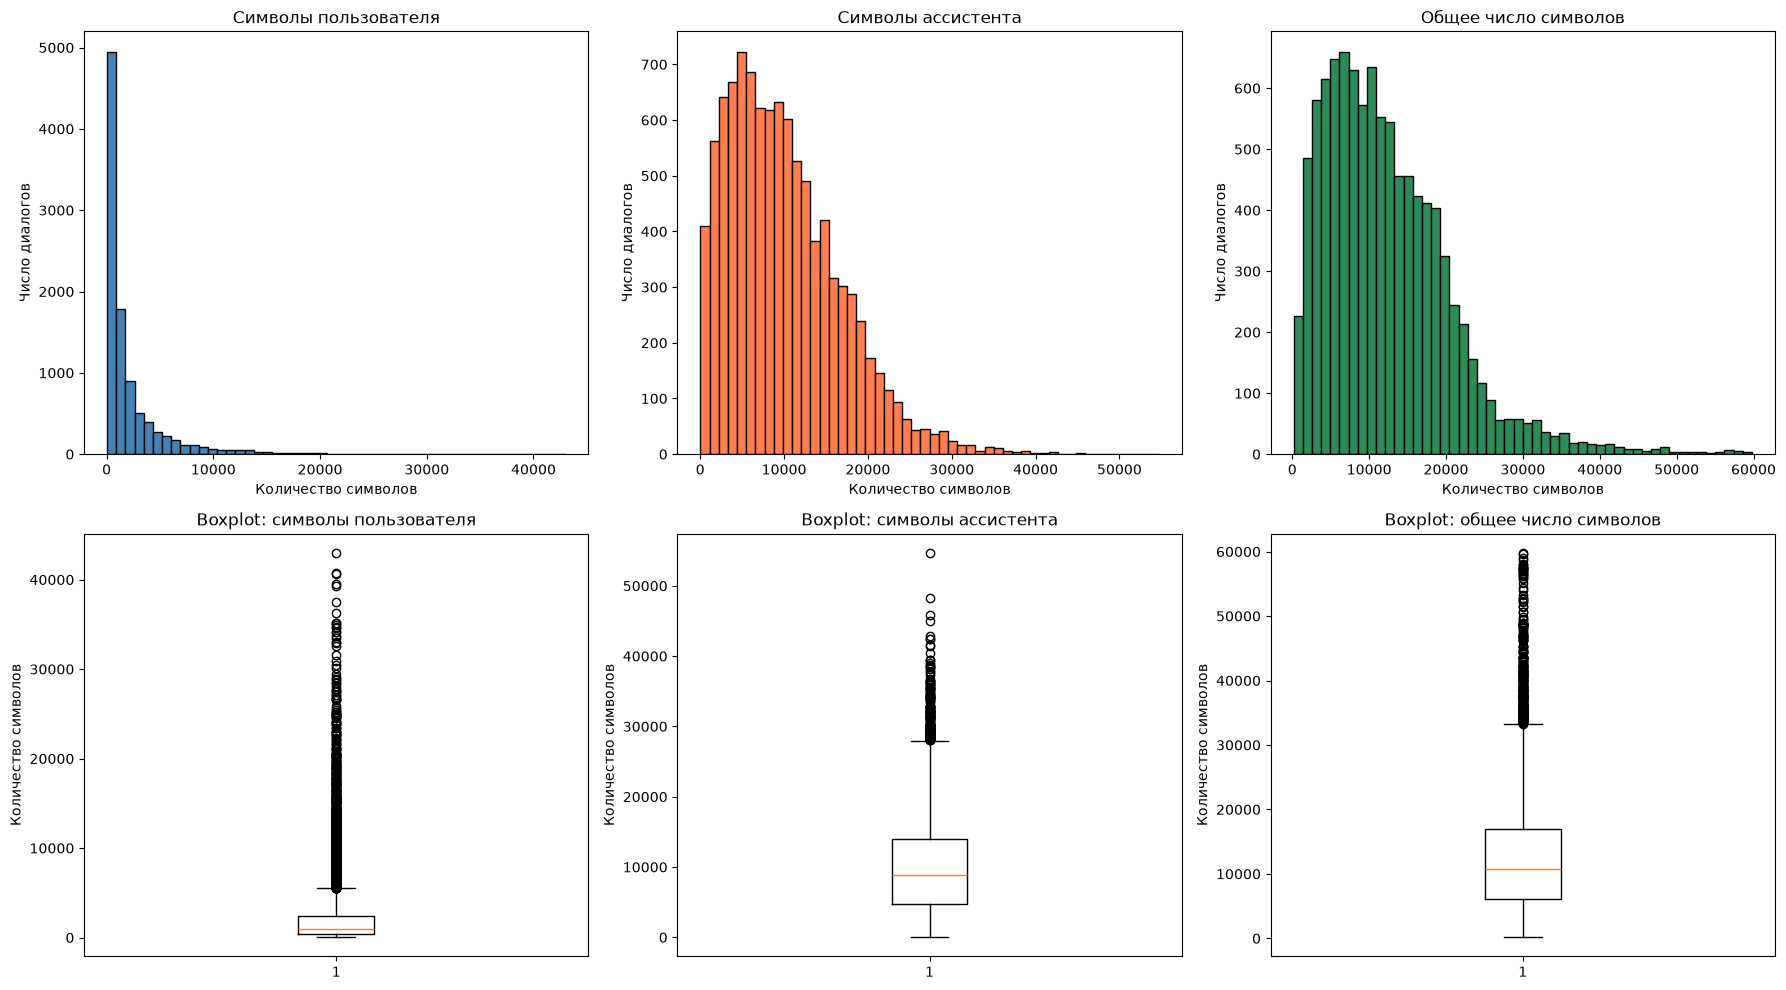

In [9]:
# --- Анализ 1: количество реплик ---
stats_turns = analyze_dialog_lengths_by_turns(general_data_df)
for who, s in stats_turns.items():
    print(f"--- {who} ---")
    print(f"  min={s['min']}, max={s['max']}, mean={s['mean']:.2f}, "
          f"median={s['median']}, std={s['std']:.2f}")
plot_dialog_lengths_by_turns(general_data_df)

# --- Анализ 2: количество символов ---
stats_chars = analyze_dialog_lengths_by_chars(general_data_df)
for who, s in stats_chars.items():
    print(f"--- {who} ---")
    print(f"  min={s['min']}, max={s['max']}, mean={s['mean']:.2f}, "
          f"median={s['median']}, std={s['std']:.2f}")
    print(f"  квантили: q25={s['q25']:.1f}, q50={s['q50']:.1f}, "
          f"q75={s['q75']:.1f}, q90={s['q90']:.1f}")
plot_dialog_lengths_by_chars(general_data_df)